In [16]:
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split

diabetes = load_diabetes()
X, y = diabetes.data, diabetes.target
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [17]:
import numpy as np 

def linreg_normal_equation(X, y):
    X_b = np.c_[np.ones(len(X)), X]
    w = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
    return w

In [18]:
def linreg_gradient_descent(X, y, lr=0.1, n_iters=1000):
    X_b = np.c_[np.ones(len(X)), X]
    m, n = X_b.shape
    w = np.zeros(n)
    history = []

    for i in range(n_iters):
        y_pred = X_b @ w
        error = y_pred - y
        grad = (2 / m) * X_b.T @ error
        w = w -lr * grad
        history.append(np.mean(error ** 2))
    return w, history

In [19]:
def predict(X, w):
    X_b = np.c_[np.ones(len(X)), X]
    return X_b @ w

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# A. 정규방정식
w_normal = linreg_normal_equation(X_train, y_train)
pred_normal = predict(X_test, w_normal)

# sklearn
sk = LinearRegression().fit(X_train, y_train)
pred_sk = sk.predict(X_test)

print("정규방정식 R²:", r2_score(y_test, pred_normal))
print("sklearn   R²:", r2_score(y_test, pred_sk))
print("절편 비교:", w_normal[0], "vs", sk.intercept_)
print("계수 거의 일치:", np.allclose(w_normal[1:], sk.coef_))

정규방정식 R²: 0.4526027629719186
sklearn   R²: 0.4526027629719198
절편 비교: 151.34560453986 vs 151.34560453985995
계수 거의 일치: True


In [21]:
w_gd, history = linreg_gradient_descent(X_train, y_train, lr=0.1, n_iters=2000)
pred_gd = predict(X_test, w_gd)

print("경사하강 R²:", r2_score(y_test, pred_gd))
print("경사하강 w :", np.round(w_gd, 2))
print("정규방정식 w:", np.round(w_normal, 2))

경사하강 R²: 0.45121679150984406
경사하강 w : [ 151.77   56.31 -105.41  384.05  262.57   -9.27  -48.83 -189.16  149.34
  299.16  148.34]
정규방정식 w: [ 151.35   37.9  -241.96  542.43  347.7  -931.49  518.06  163.42  275.32
  736.2    48.67]


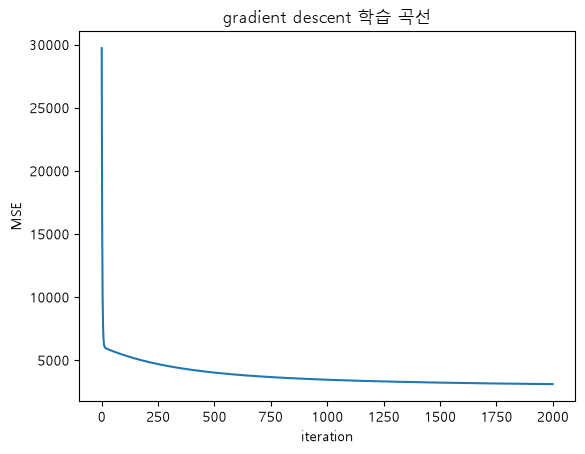

In [23]:
import matplotlib.pyplot as plt

# 한글 폰트 설정 (Windows 기본 폰트: 맑은 고딕)
plt.rc('font', family='Malgun Gothic')

# 마이너스 기호(-) 깨짐 방지
plt.rc('axes', unicode_minus=False)

plt.plot(history)
plt.xlabel("iteration")
plt.ylabel("MSE")
plt.title("gradient descent 학습 곡선")
plt.show()
# MSE가 가파르게 떨어지다 평평해진다 = 최소에 수렴

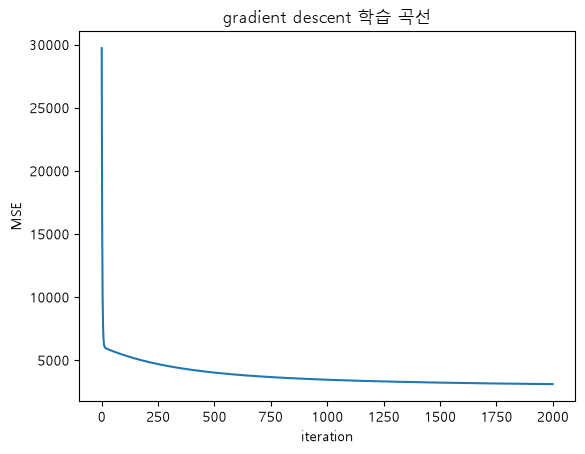

In [24]:
import matplotlib.pyplot as plt

plt.plot(history)
plt.xlabel("iteration")
plt.ylabel("MSE")
plt.title("gradient descent 학습 곡선")
plt.show()
# MSE가 가파르게 떨어지다 평평해진다 = 최소에 수렴